In [1]:
# pip install torchdiffeq

In [1]:
import os
import time
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch.nn.functional as F

from torchdiffeq import odeint_adjoint as odeint

In [2]:
eval_size = 10000
data_size = 100
batch_length = 30
batch_size = 20
niters = 500
test_freq = 100
adjoint = True
alpha, beta = 0.2, 0.025

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Text(0.5, 0, 'Time')

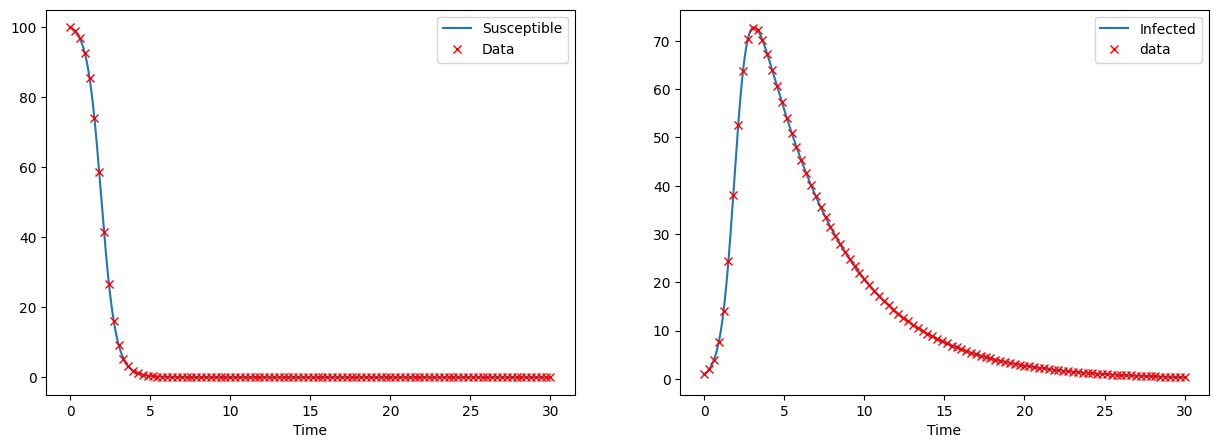

In [3]:
# index of data points
ind_data = np.linspace(0, eval_size-1, data_size).astype(int)
# Set initial values as (S, I) = (100, 1)
true_y0 = torch.tensor([[100., 1.]]).to(device)
# generate eval_size data within (0, 30)
t = torch.linspace(0., 30., eval_size).to(device)
true_A = torch.tensor([[-beta, beta], [0., -alpha]]).to(device)

class SIR(nn.Module):
    def forward(self, t, y):
        y_mod = y.clone()
        y_mod[:, 0] = y[:, 0] * y[:, 1]  # 안전하게 복사 후 수정
        return torch.mm(y_mod, true_A)

with torch.no_grad():
    true_y = odeint(SIR(), true_y0, t, method='dopri5')

t_data = t[ind_data].to(device)
data_y = true_y[ind_data].to(device)

figure = plt.figure(figsize=(15,5))
ax1 = figure.add_subplot(1,2,1)
ax1.plot(t.cpu(), true_y.squeeze()[:, 0].cpu(), color='C0', label="Susceptible")  # 파란 선
ax1.plot(t_data.cpu(), data_y.squeeze()[:, 0].cpu(), 'x', color='red', label="Data")  # 오렌지 X표
ax1.legend()
ax1.set_xlabel('Time')

ax2 = figure.add_subplot(1,2,2)
ax2.plot(t.cpu(), true_y.squeeze()[:,1].cpu(), color='C0', label="Infected")
ax2.plot(t_data.cpu(), data_y.squeeze()[:,1].cpu(), 'x', color='red', label="data")
ax2.legend()
ax2.set_xlabel('Time')

In [4]:
def get_batch():
    s = torch.from_numpy(np.random.choice(np.arange(data_size - batch_length, dtype=np.int64),
                                          batch_size, replace=False))
    # starting y value(S, I) of each batch data
    # batch_y0.size() = (batch_size, 1, 2)
    # where (1, 2) represents the shape of each data point. Note that the initial data had shape (1, 2).
    batch_y0 = data_y[s]
    # A time vector indicating the evaluation points for each batch sequence, starting from its own initial time. It must always begin at 0.
    batch_t = t_data[:batch_length]
    # batch_y[0] = batch_y0
    # batch_y[1] = batch_y1 ...
    # batch_y.size() = (batch_length, batch_size, 1, 2)
    batch_y = torch.stack([data_y[s + i] for i in range(batch_length)], dim=0)
    return batch_y0.to(device), batch_t.to(device), batch_y.to(device)

# get a value of (S, I) and return (dS/dt, dI/dt) at the given point.
class ODEFunc(nn.Module):
    def __init__(self, hidden_dims):
        super(ODEFunc, self).__init__()

        self.layers = []
        for i in range(len(hidden_dims)-1):
            self.layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
        self.layers = nn.ModuleList(self.layers)

        for layer in self.layers:
            nn.init.xavier_uniform_(layer.weight)

        self.act = nn.Tanh()

    def forward(self, t, x):
        for layer in self.layers[:-1]:
            x = self.act(layer(x))
        x = self.layers[-1](x)
        return x

In [7]:
func = ODEFunc([2, 64 ,2]).to(device)

optimizer = optim.Adam(func.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=int(niters/4), gamma=0.5)

Loss_list = []

func.train()
for itr in range(1, niters + 1):
    optimizer.zero_grad()
    batch_y0, batch_t, batch_y = get_batch()
    pred_y = odeint(func, batch_y0, batch_t).to(device)
    loss = torch.mean(torch.abs(pred_y - batch_y))
    loss.backward()
    optimizer.step()
    scheduler.step()

    Loss_list.append(loss.item())

    if itr % test_freq == 0:
        with torch.no_grad():
            pred_y = odeint(func, true_y0, t)
            loss = torch.mean(torch.abs(pred_y - true_y))
            print(f"Iter {itr:04d} | Total Loss {loss.item():.6f}")
        clear_output(wait=True)

KeyboardInterrupt: 

In [ ]:
func.eval()

eval_y = odeint(func, true_y0, t)
eval_y = eval_y.squeeze()

figure = plt.figure(figsize=(15,5))
ax1 = figure.add_subplot(1,2,1)
ax1.plot(t.cpu(), eval_y[:,0].cpu().detach().numpy(), label="prediction", linestyle='--')
ax1.plot(t.cpu(), true_y.squeeze()[:,0].cpu(), label="Susceptible")
ax1.legend()
ax1.set_xlabel('Time')

ax2 = figure.add_subplot(1,2,2)
ax2.plot(t.cpu(), eval_y[:,1].cpu().detach().numpy(), label="prediction", linestyle='--')
ax2.plot(t_data.cpu(), data_y.squeeze()[:,1].cpu(), label="data")
ax2.legend()
ax2.set_xlabel('Time')

NameError: name 'func' is not defined

Text(0.5, 1.0, 'Training Loss in log scale')

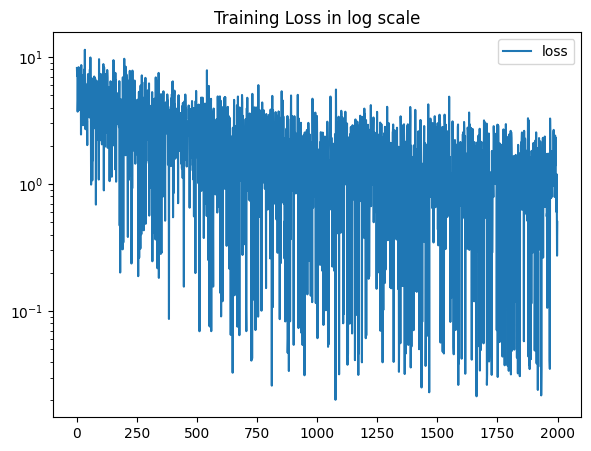

In [ ]:
figure = plt.figure(figsize=(15,5))

ax1 = figure.add_subplot(1,2,1)
ax1.plot(Loss_list, label='loss')
ax1.set_yscale('log')
ax1.legend()
ax1.set_title('Training Loss in log scale')